# 04c · Theme 3: Creator and Collaboration

Who posts brand-related content, in what form, for which brand, and with what within-brand engagement (BRI).

**Definitions.** Official = brand-owned accounts (`is_official_brand`). UGC = all other authors in this top-search sample. `content_type = collaboration` is rule-based caption language, not a verified commercial deal. Partner fields from LLM caption enrichment are caption-inferred only.

**Sample.** 4,457 search-visible Nike and Adidas videos. Descriptive associations only.

**Sections**
1. Creator landscape
2. Brand use of the creator ecosystem
3. Creator scale × content × BRI (UGC)
4. Collaboration
5. Summary


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from IPython.display import Markdown, display
import matplotlib.pyplot as plt

def _show_fig(fig):
    import io
    from IPython.display import Image, display
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    display(Image(buf.getvalue()))

from tiktok_brand.analysis.data import CLUSTER_COL, load_feature_table, project_paths
from tiktok_brand.analysis.influencer import (
    CREATOR_CONTENT_DIMS,
    add_creator_flags,
    brand_channel_summary,
    collab_brand_channel,
    collab_content_mix,
    collab_vs_rest,
    partner_type_mix,
    scale_x_dimension,
    scale_x_dimension_wide,
    ugc_frame,
    ugc_tier_mix,
)
from tiktok_brand.analysis.plots import (
    brand_channel_share_bars,
    scale_content_bri_heatmap,
    ugc_tier_share_bars,
)
from tiktok_brand.analysis.present import format_cluster_label, humanize_label

import os
os.chdir(ROOT)
PATHS = project_paths(ROOT / "configs" / "project.yaml")
df = load_feature_table(PATHS["feature_table"])
df["content_cluster"] = df[CLUSTER_COL].map(format_cluster_label)
df = add_creator_flags(df)

ugc = ugc_frame(df)
print(
    f"rows={len(df):,}  ugc={len(ugc):,} ({len(ugc)/len(df):.1%})  "
    f"official={int(df['is_official_brand'].sum()):,}  "
    f"collab={int(df['is_collaboration'].sum()):,} ({df['is_collaboration'].mean():.1%})"
)


rows=4,457  ugc=3,185 (71.5%)  official=1,272  collab=146 (3.3%)


## 1. Creator landscape

Official accounts are concentrated in macro/mega follower bins. Creator-scale tables therefore use **UGC only**; Official vs UGC is reported as channel mix in Section 2.

| Tier | Followers (approx.) |
|------|---------------------|
| nano | < 10k |
| micro | 10k–100k |
| mid | 100k–1M |
| macro | 1M–10M |
| mega | ≥ 10M |

Bins are practical for this sample, not industry standards.


In [2]:
# Landscape snapshot
n_key = "video_id" if "video_id" in df.columns else "brand"
channel = (
    df.groupby("creator_channel", observed=True)
    .agg(
        n=(n_key, "size"),
        authors=("author_id", "nunique"),
        median_bri=("brand_relative_engagement_index", "median"),
        median_views=("view_count", "median"),
    )
    .reset_index()
)
channel["share"] = channel["n"] / channel["n"].sum()
display(
    channel.style.format(
        {
            "share": "{:.1%}",
            "median_bri": "{:.2f}",
            "median_views": "{:,.0f}",
            "n": "{:,}",
            "authors": "{:,}",
        }
    ).hide(axis="index")
)

tier_all = ugc_tier_mix(df)
tier_overall = tier_all.loc[
    tier_all["scope"] == "all",
    ["creator_tier", "authors", "n", "author_share", "video_share"],
].copy()
tier_overall["creator_tier"] = tier_overall["creator_tier"].astype(str).str.title()
tier_overall = tier_overall.rename(
    columns={
        "authors": "Authors",
        "n": "Videos (n)",
        "author_share": "Author share",
        "video_share": "Video share",
    }
)
display(Markdown("**UGC creator-tier mix** (unique authors; n = videos)"))display(
    tier_overall.style.format(
        {
            "Authors": "{:,}",
            "Videos (n)": "{:,}",
            "Author share": "{:.1%}",
            "Video share": "{:.1%}",
        }
    ).hide(axis="index")
)

ugc_share = len(ugc) / len(df)
off_n = int(df["is_official_brand"].sum())
off_share = df["is_official_brand"].mean()


creator_channel,n,authors,median_bri,median_views,share
official,"1,272",3,0.80,"130,290",28.5%
ugc,"3,185","2,641",1.09,"98,579",71.5%


**UGC creator-tier mix** (unique authors; n = videos)

creator_tier,Authors,Videos (n),Author share,Video share
Nano,"1,324","1,423",50.1%,44.7%
Micro,760,917,28.8%,28.8%
Mid,443,679,16.8%,21.3%
Macro,101,147,3.8%,4.6%
Mega,13,19,0.5%,0.6%


## 2. Brand use of the creator ecosystem

Official vs UGC share, UGC tier mix, and collaboration frequency by brand.


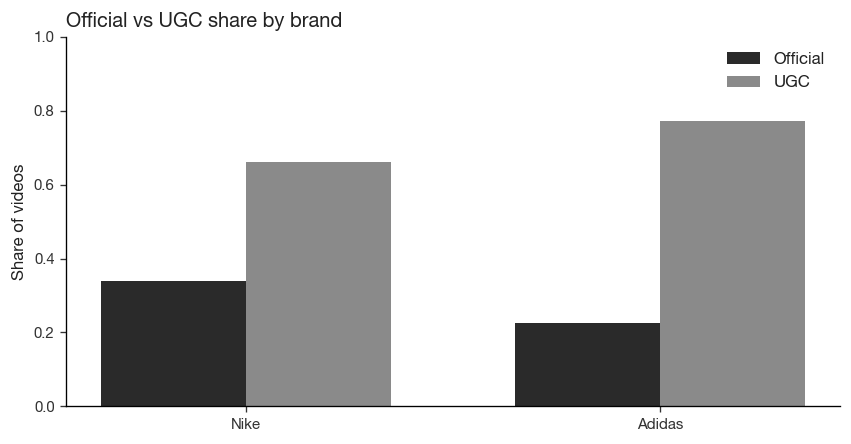

brand,N,Official Share,UGC Share,Collab N,Collab Rate
Nike,"2,317",34.0%,66.0%,69,3.0%
Adidas,"2,140",22.7%,77.3%,77,3.6%


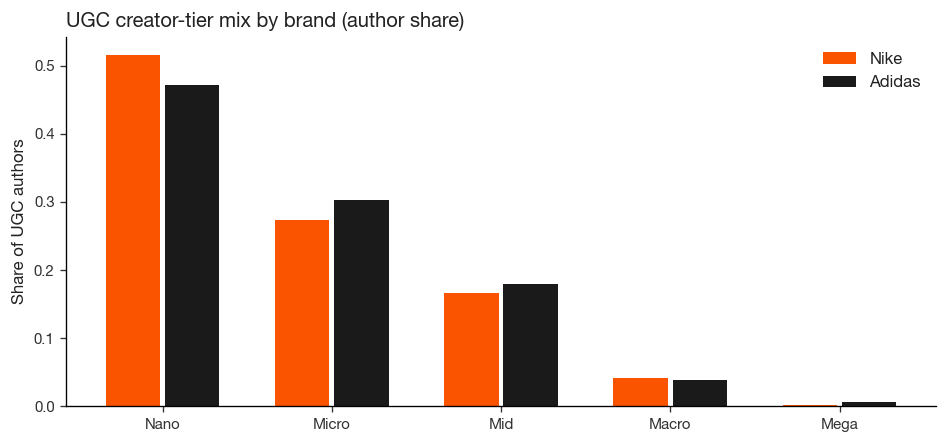

In [3]:
summary = brand_channel_summary(df)
_show_fig(brand_channel_share_bars(summary))

show = summary.copy()
show["brand"] = show["brand"].str.title()
show = show.rename(
    columns={
        "n": "N",
        "official_share": "Official Share",
        "ugc_share": "UGC Share",
        "collab_rate": "Collab Rate",
        "collab_n": "Collab N",
    }
)
display(
    show[["brand", "N", "Official Share", "UGC Share", "Collab N", "Collab Rate"]]
    .style.format(
        {
            "N": "{:,}",
            "Official Share": "{:.1%}",
            "UGC Share": "{:.1%}",
            "Collab Rate": "{:.1%}",
            "Collab N": "{:,}",
        }
    )
    .hide(axis="index")
)

mix = ugc_tier_mix(df)
_show_fig(
    ugc_tier_share_bars(
        mix,
        title="UGC creator-tier mix by brand (author share)",
    )
)

nike = summary.loc[summary["brand"] == "nike"].iloc[0]
adi = summary.loc[summary["brand"] == "adidas"].iloc[0]


## 3. Creator scale × content × performance

UGC only. `creator_tier` × content form → *n* and median BRI. Primary axis: `content_type`; also `brand_styles` and `content_cluster`. Cells with *n* < 15 omitted.


### 3.1 Scale × Content type

scale,level,n,median_bri
Nano,Vibe OOTD,102,1.26
Nano,Collaboration,24,1.24
Nano,Product Promo,22,1.17
Nano,Product Showcase,62,1.02
Nano,Tutorial Utility,16,0.90
Nano,Product Review,45,0.74
Micro,Vibe OOTD,99,1.20
Micro,Collaboration,31,0.99
Micro,Product Review,42,0.92
Micro,Tutorial Utility,17,0.91


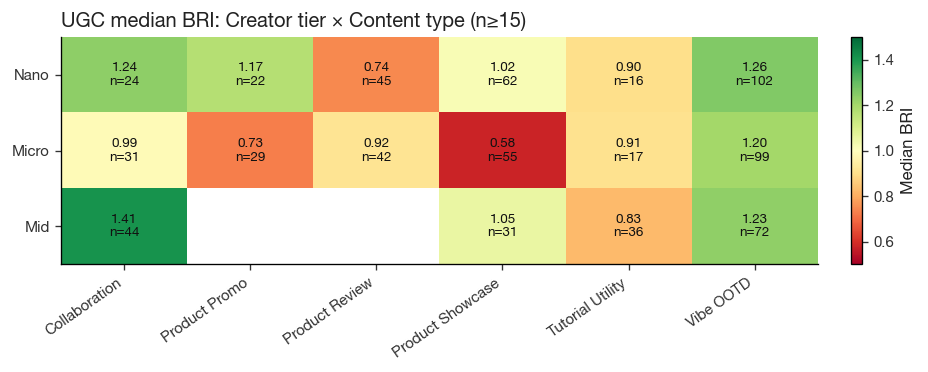

### 3.2 Scale × Brand style

scale,level,n,median_bri
Nano,Technical,51,1.38
Nano,Lifestyle,170,1.09
Nano,Retro,29,1.04
Nano,Performance,152,0.98
Micro,Technical,37,1.20
Micro,Lifestyle,163,1.12
Micro,Performance,65,0.71
Micro,Retro,16,0.61
Mid,Performance,46,1.22
Mid,Technical,20,1.09


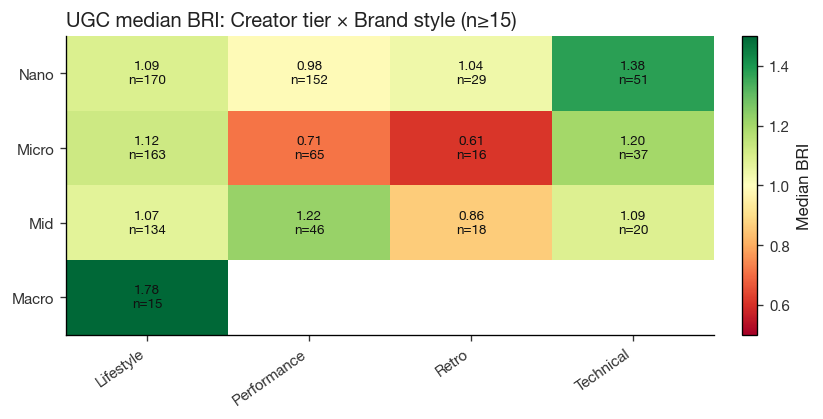

### 3.3 Scale × Content cluster

scale,level,n,median_bri
Nano,5 — Elite Athlete Stories & Sporting Moments,28,1.71
Nano,9 — Football Athletes & Adidas Football Culture,72,1.67
Nano,8 — Short Promotional & Reaction Content,138,1.37
Nano,4 — Basketball Athletes & Signature Footwear,54,1.36
Nano,"6 — Running Shoes, Training & Marathon Culture",196,1.29
Nano,"0 — Ootd, Outfit Inspiration & Streetwear",215,1.25
Nano,"3 — Interactive Brand, Creator & Pop-Culture Content",144,1.12
Nano,"1 — Jordan Brand Culture, Releases & Community",23,1.05
Nano,10 — Nike Air Product Lines & Commerce,74,1.03
Nano,"11 — Adidas Originals, Lifestyle & Classic Sneaker Lines",98,0.98


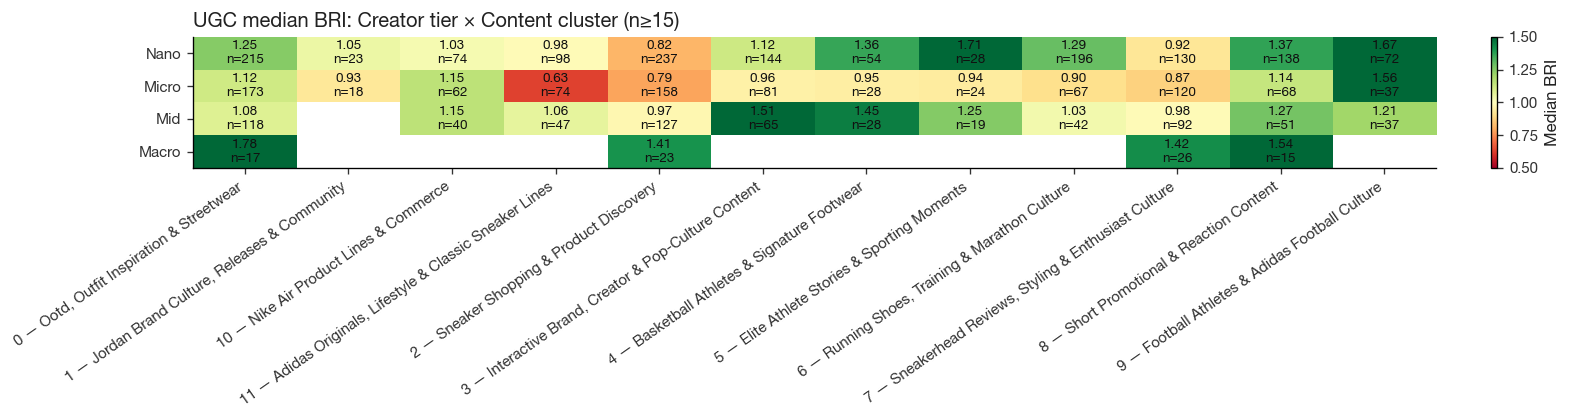

In [4]:
DIM_LABELS = {
    "content_type": "Content type",
    "brand_styles": "Brand style",
    "content_cluster": "Content cluster",
}

MIN_N = 15
tabs = {}
for dim in CREATOR_CONTENT_DIMS:
    if dim not in df.columns:
        print(f"skip missing: {dim}")
        continue
    long = scale_x_dimension(df, dim, min_count=MIN_N)
    wide = scale_x_dimension_wide(df, dim, min_count=MIN_N)
    tabs[dim] = (long, wide)
    title = DIM_LABELS.get(dim, dim)
    idx = list(CREATOR_CONTENT_DIMS).index(dim) + 1
    display(Markdown(f"### 3.{idx} Scale × {title}"))
    if long.empty:
        print("No cells meet min_count")
        continue
    show = long.copy()
    show["scale"] = show["scale"].astype(str).str.title()
    show["level"] = show["level"].map(humanize_label)
    display(
        show[["scale", "level", "n", "median_bri"]]
        .style.format({"median_bri": "{:.2f}", "n": "{:,}"})
        .hide(axis="index")
    )
    n_counts = wide.attrs.get("n_counts")
    _show_fig(
        scale_content_bri_heatmap(
            wide,
            title=f"UGC median BRI: Creator tier × {title} (n≥{MIN_N})",
            n_counts=n_counts,
        )
    )


In [5]:
ct_long, _ = tabs["content_type"]
stable = ct_long.loc[ct_long["n"] >= 20].sort_values("median_bri", ascending=False).head(8).copy()
stable["scale"] = stable["scale"].astype(str)
stable["level"] = stable["level"].map(humanize_label)
display(Markdown("**Highest median-BRI cells (content type, n≥20)**"))display(
    stable[["scale", "level", "n", "median_bri"]]
    .style.format({"median_bri": "{:.2f}", "n": "{:,}"})
    .hide(axis="index")
)

low = ct_long.loc[ct_long["n"] >= 20].sort_values("median_bri", ascending=True).head(5).copy()
low["scale"] = low["scale"].astype(str)
low["level"] = low["level"].map(humanize_label)
display(Markdown("**Lowest median-BRI cells (content type, n≥20)**"))display(
    low[["scale", "level", "n", "median_bri"]]
    .style.format({"median_bri": "{:.2f}", "n": "{:,}"})
    .hide(axis="index")
)


**Highest median-BRI cells (content type, n≥20)**

scale,level,n,median_bri
mid,Collaboration,44,1.41
nano,Vibe OOTD,102,1.26
nano,Collaboration,24,1.24
mid,Vibe OOTD,72,1.23
micro,Vibe OOTD,99,1.20
nano,Product Promo,22,1.17
mid,Product Showcase,31,1.05
nano,Product Showcase,62,1.02


**Lowest median-BRI cells (content type, n≥20)**

scale,level,n,median_bri
micro,Product Showcase,55,0.58
micro,Product Promo,29,0.73
nano,Product Review,45,0.74
mid,Tutorial Utility,36,0.83
micro,Product Review,42,0.92


### Section 3 note

Within UGC, no creator tier dominates uniformly. Vibe/OOTD remains above baseline across Nano, Micro, and Mid (median BRI ≈ 1.20–1.26); Lifestyle style is similarly stable. Specialized formats vary by tier (e.g. Collaboration stronger for Mid/Nano; Technical stronger among Nano; Performance stronger among Mid). Lifestyle content is relatively portable; specialized themes depend more on creator–content fit.


## 4. Collaboration

Videos tagged `content_type = collaboration`. Reports brand × channel mix, collab vs non-collab outcomes, co-occurring content types, and caption-inferred partner type/name/role.


In [6]:
import pandas as pd

collab_n = int(df["is_collaboration"].sum())
display(Markdown(f"**Collaboration videos:** n={collab_n:,} ({100*df['is_collaboration'].mean():.1f}% of sample)"))
cc = collab_brand_channel(df)
show_cc = cc.copy()
show_cc["brand"] = show_cc["brand"].str.title()
show_cc["channel"] = show_cc["channel"].astype(str).str.title()
display(Markdown("**4.1 Brand × channel**"))display(
    show_cc.style.format(
        {
            "n": "{:,}",
            "median_bri": "{:.2f}",
            "median_wer": "{:.4f}",
            "median_sentiment": "{:.2f}",
        }
    ).hide(axis="index")
)

cmp_ = collab_vs_rest(df)
show_cmp = cmp_.copy()
show_cmp["group"] = show_cmp["group"].map(
    {"collaboration": "Collaboration", "non_collaboration": "Non-collaboration"}
)
display(Markdown("**4.2 Collab vs non-collab**"))fmt = {
    "n": "{:,}",
    "median_bri": "{:.2f}",
    "median_wer": "{:.4f}",
    "median_views": "{:,.0f}",
}
if "median_sentiment" in show_cmp.columns:
    fmt["median_sentiment"] = "{:.2f}"
    fmt["sentiment_coverage"] = "{:.1%}"
display(show_cmp.style.format(fmt).hide(axis="index"))

cmix = collab_content_mix(df, min_count=5)
cmix_show = cmix.copy()
cmix_show["level"] = cmix_show["level"].map(humanize_label)
display(Markdown("**4.3 Co-occurring content types on collaboration videos**"))display(
    cmix_show.style.format({"n": "{:,}", "median_bri": "{:.2f}", "share": "{:.1%}"})
    .hide(axis="index")
)

pt = partner_type_mix(df)
partner_bit = ""
if pt is None or pt.empty:
    display(Markdown("**4.4 Partner type.** LLM columns not found on feature table."))
else:
    display(Markdown(
        "**4.4 Partner type (LLM).** `brand` = another commercial brand/org as partner "
        "(not Nike/Adidas self). Caption-inferred only."
    ))
    pt_show = pt.copy()
    pt_show["collab_partner_type"] = pt_show["collab_partner_type"].map(
        lambda x: humanize_label(x) if pd.notna(x) else x
    )
    display(
        pt_show.style.format({"n": "{:,}", "median_bri": "{:.2f}", "share": "{:.1%}"})
        .hide(axis="index")
    )

    # Role mix on collab videos
    collab = df.loc[df["is_collaboration"]].copy()
    role = (
        collab.groupby("collab_role", dropna=False)
        .agg(n=("video_id", "size"), median_bri=("brand_relative_engagement_index", "median"))
        .reset_index()
        .sort_values("n", ascending=False)
    )
    role["share"] = role["n"] / len(collab)
    role["collab_role"] = role["collab_role"].map(
        lambda x: humanize_label(x) if pd.notna(x) else x
    )
    display(Markdown("**4.5 Collab role (LLM)**"))
    display(
        role.style.format({"n": "{:,}", "median_bri": "{:.2f}", "share": "{:.1%}"})
        .hide(axis="index")
    )

    xt = pd.crosstab(
        collab["collab_partner_type"].fillna("(null)").map(
            lambda x: humanize_label(x) if x != "(null)" else x
        ),
        collab["brand"].str.title(),
        margins=True,
    )
    display(Markdown("**4.6 Partner type × brand (counts)**"))
    display(xt)

    top = pt.sort_values("n", ascending=False).iloc[0]
    partner_bit = (
        f" Among collab videos, LLM partner types: "
        f"{humanize_label(top['collab_partner_type'])} leads "
        f"(n={int(top['n'])}, {100*top['share']:.0f}%, median BRI {top['median_bri']:.2f}). "
        f"Artist / creator cells are smaller; athlete n is small. "
        f"`none` means no clear external partner in the caption."
    )

c_row = cmp_.loc[cmp_["group"] == "collaboration"].iloc[0]
n_row = cmp_.loc[cmp_["group"] == "non_collaboration"].iloc[0]
nike_off = int(cc.loc[(cc["brand"] == "nike") & (cc["channel"].astype(str) == "official"), "n"].iloc[0])
nike_ugc = int(cc.loc[(cc["brand"] == "nike") & (cc["channel"].astype(str) == "ugc"), "n"].iloc[0])
adi_off = int(cc.loc[(cc["brand"] == "adidas") & (cc["channel"].astype(str) == "official"), "n"].iloc[0])
adi_ugc = int(cc.loc[(cc["brand"] == "adidas") & (cc["channel"].astype(str) == "ugc"), "n"].iloc[0])
views_cmp = "higher" if c_row["median_views"] > n_row["median_views"] else "lower"
sent_bit = ""
if "median_sentiment" in cmp_.columns:
    sent_bit = (
        f" Median caption sentiment is {c_row['median_sentiment']:.2f} on collab vs "
        f"{n_row['median_sentiment']:.2f} on non-collab "
        f"(coverage {100*c_row['sentiment_coverage']:.0f}% / {100*n_row['sentiment_coverage']:.0f}%)."
    )
# Nike collab channel performance (descriptive)
nike_cc = cc.loc[cc["brand"] == "nike"].set_index(cc.loc[cc["brand"] == "nike", "channel"].astype(str))
nike_off_bri = float(nike_cc.loc["official", "median_bri"]) if "official" in nike_cc.index else float("nan")
nike_ugc_bri = float(nike_cc.loc["ugc", "median_bri"]) if "ugc" in nike_cc.index else float("nan")

# LLM partner framing for interpretation
partner_bit = ""
if pt is not None and not pt.empty:
    ident = pt.loc[pt["collab_partner_type"].astype(str) != "none"]
    n_ident = int(ident["n"].sum()) if len(ident) else 0
    n_brand = int(ident.loc[ident["collab_partner_type"].astype(str) == "brand", "n"].sum()) if n_ident else 0
    brand_share = (n_brand / n_ident) if n_ident else float("nan")
    n_product = int((df.loc[df["is_collaboration"], "collab_role"].astype(str) == "product_collab").sum())
    partner_bit = (
        f" Among collaborations with an identifiable partner type (n={n_ident}), "
        f"{100*brand_share:.0f}% involve another brand or organization "
        f"({n_brand}/{n_ident}). Artist, creator, and athlete partnerships form smaller segments. "
        f"Product collaborations account for half of collab posts ({n_product}/{collab_n}). "
        f"Overall, the observed collaboration ecosystem is primarily product- and brand-partnership led."
    )


**Collaboration videos:** n=146 (3.3% of sample)

**4.1 Brand × channel**

brand,channel,n,median_bri,median_wer,median_sentiment
Nike,Official,34,0.95,0.0056,0.32
Nike,Ugc,35,1.45,0.0086,0.34
Adidas,Official,3,0.47,0.0033,-0.27
Adidas,Ugc,74,1.13,0.0079,0.28


**4.2 Collab vs non-collab**

group,n,median_bri,median_wer,median_views,median_sentiment,sentiment_coverage
Collaboration,146,1.13,0.0074,"82,682",0.31,94.5%
Non-collaboration,"4,311",1.00,0.0064,"114,588",0.00,84.8%


...

collab_partner_type,n,median_bri,share
Brand,60,1.26,41.1%
Unclassified,51,1.09,34.9%
Artist,15,1.12,10.3%
Creator,9,1.14,6.2%
Athlete,8,0.78,5.5%
Other,3,1.04,2.1%


**4.5 Collab role (LLM)**

collab_role,n,median_bri,share
Product Collab,73,1.22,50.0%
Unclear,25,1.01,17.1%
Feature,20,0.90,13.7%
Campaign,15,1.33,10.3%
Gifted,13,1.62,8.9%


**4.6 Partner type × brand (counts)**

brand,Adidas,Nike,All
collab_partner_type,,,
Artist,8,7,15
Athlete,1,7,8
Brand,26,34,60
Creator,2,7,9
Other,1,2,3
Unclassified,39,12,51
All,77,69,146


## 5. Summary

1. **Channel mix.** Of 4,457 videos, 71.5% are UGC and 28.5% are official. Official posts have higher median reach (~130k vs ~99k views); UGC has higher median BRI (1.09 vs 0.80). Scale analysis is UGC-only.

2. **Brand mix.** Nike has a larger official share (34.0% vs Adidas 22.7%); Adidas has a larger UGC share (77.3% vs 66.0%). Search-visible mix only.

3. **Creator × content.** No UGC tier is uniformly strongest. Vibe/OOTD (and Lifestyle style) travel across Nano–Mid. Collaboration, Technical, and Performance are more tier-dependent. Scale alone is a weak guide.

4. **Collaboration volume and outcomes.** Collaboration language appears on 146 videos (3.3%). Relative to non-collab: higher median BRI (1.13 vs 1.00), higher median WER (0.74% vs 0.64%), more positive caption sentiment, lower median views (~83k vs ~115k).

5. **Collaboration structure.** Nike splits collab visibility across owned and UGC; Adidas collabs are mostly UGC-side. Among partners with a typed label (*n*=95), 63% are brand/organization; product collaborations are 73/146. Caption-inferred; not verified deals.
